In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("/content/healthcare_dataset.csv")

In [25]:
print("Original Data:")
print(df.head())

Original Data:
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    1

In [26]:
print(df.shape)

(55430, 15)


In [27]:
print(df.describe())

               Age  Billing Amount   Room Number
count  55430.00000    55429.000000  55429.000000
mean      51.54079    25540.271554    301.137022
std       19.60167    14211.289455    115.247222
min       13.00000    -2008.492140    101.000000
25%       35.00000    13240.597252    202.000000
50%       52.00000    25538.524706    302.000000
75%       68.00000    37820.565865    401.000000
max       89.00000    52764.276736    500.000000


In [28]:
df = df.dropna()

In [29]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [30]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"]
)

In [31]:
df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"]
)

In [32]:
print("\nStandardized Dates:")
print(df[["Date of Admission", "Discharge Date"]].head())


Standardized Dates:
  Date of Admission Discharge Date
0        2024-01-31     2024-02-02
1        2019-08-20     2019-08-26
2        2022-09-22     2022-10-07
3        2020-11-18     2020-12-18
4        2022-09-19     2022-10-09


In [33]:
df["Urgency"] = df["Admission Type"].map({
    "Emergency": "Emergency",
    "Elective": "Elective",
    "Urgent": "Urgent"
})

In [34]:
print("\nAdmission Urgency:")
print(df[["Admission Type", "Urgency"]].head())


Admission Urgency:
  Admission Type    Urgency
0         Urgent     Urgent
1      Emergency  Emergency
2      Emergency  Emergency
3       Elective   Elective
4         Urgent     Urgent


In [35]:
df["Stay_Days"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

In [36]:
print("\nBilling Amount Statistics:")
print(df["Billing Amount"].describe())


Billing Amount Statistics:
count    55429.000000
mean     25540.271554
std      14211.289455
min      -2008.492140
25%      13240.597252
50%      25538.524706
75%      37820.565865
max      52764.276736
Name: Billing Amount, dtype: float64


In [37]:
print("\nHospital Stay Statistics:")
print(df["Stay_Days"].describe())


Hospital Stay Statistics:
count    55429.000000
mean        15.510365
std          8.658497
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Stay_Days, dtype: float64


In [38]:
demographics = df.groupby(
    "Medical Condition"
)["Age"].agg(["count", "mean"])

In [39]:
print("\nDemographics by Medical Condition:")
print(demographics)


Demographics by Medical Condition:
                   count       mean
Medical Condition                  
Arthritis           9295  51.567617
Asthma              9170  51.575354
Cancer              9218  51.553808
Diabetes            9299  51.557157
Hypertension        9232  51.744042
Obesity             9215  51.243950


In [40]:
gender_distribution = pd.crosstab(
    df["Medical Condition"],
    df["Gender"]
)

In [41]:
print("\nGender Distribution by Medical Condition:")
print(gender_distribution)


Gender Distribution by Medical Condition:
Gender             Female  Male
Medical Condition              
Arthritis            4683  4612
Asthma               4544  4626
Cancer               4598  4620
Diabetes             4648  4651
Hypertension         4604  4628
Obesity              4613  4602


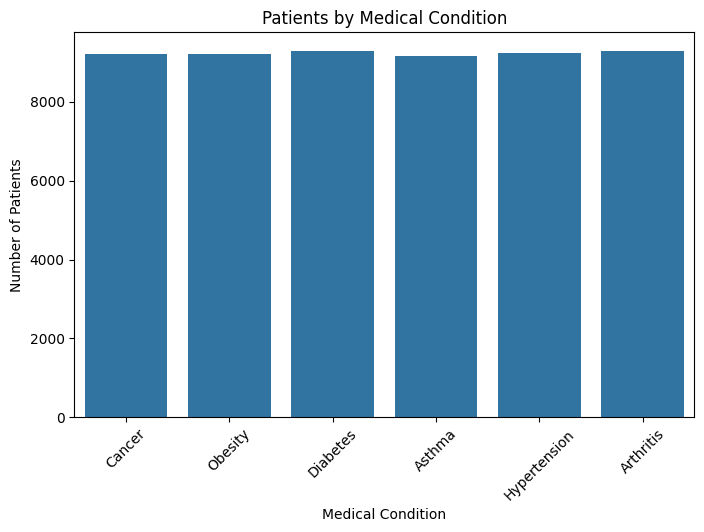

In [42]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Medical Condition"
)

plt.title("Patients by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

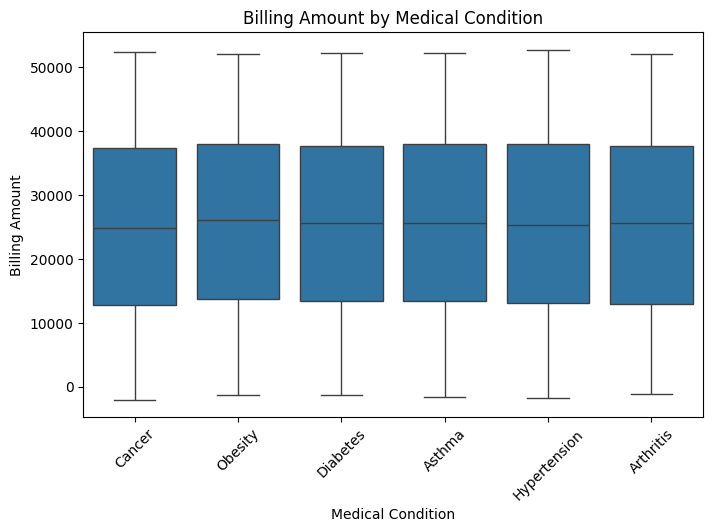

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.title("Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)

plt.show()